# COMP4030 – Data Science with Machine Learning
## Human Activity Recognition Using Smartphone Sensor Data
**University of Nottingham | Spring 2026**

---

### Research Questions
1. **RQ1 (Dimensionality):** Can PCA-reduced sensor features maintain classification accuracy compared to the full 561-feature space, and at what component threshold does performance plateau?
2. **RQ2 (Model Comparison):** Do ensemble methods (Random Forest, Gradient Boosting) significantly outperform linear baselines (Logistic Regression) on high-dimensional sensor data — as confirmed by Wilcoxon signed-rank testing?
3. **RQ3 (Generalisation):** Does a subject-independent train/test split (Leave-One-Subject-Out) reveal measurable performance degradation compared to random splitting, indicating overfitting to individual movement patterns?

## 0. Environment Setup & Reproducibility

In [ ]:
# ── Core libraries ──────────────────────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── ML libraries ──────────────────────────────────────────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.feature_selection import mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, f1_score
)
from sklearn.pipeline import Pipeline

# ── Statistical testing ────────────────────────────────────────────────────────────────────────────
from scipy.stats import wilcoxon, friedmanchisquare

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
import random
random.seed(RANDOM_SEED)

# ── Plot style ────────────────────────────────────────────────────────────────────────────────────
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (10, 5)})
sns.set_style('whitegrid')
print('Environment ready. Seed:', RANDOM_SEED)

Environment ready. Seed: 42


## 1. Data Acquisition

> The UCI HAR dataset is downloaded programmatically to ensure full reproducibility. Any reviewer can re-run this notebook from scratch and obtain identical results.

> **Source:** Anguita, D. et al. (2013). *A public domain dataset for human activity recognition using smartphones.* ESANN.

In [36]:
# Dataset: Anguita et al. (2013) — UCI Machine Learning Repository
# https://archive.ics.uci.edu/ml/datasets/human+activity+recognition+using+smartphones
import urllib.request, zipfile, os

URL = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip'
ZIP_PATH = 'UCI_HAR.zip'
DATA_DIR = 'UCI HAR Dataset'

if not os.path.exists(DATA_DIR):
    print('Downloading dataset...')
    urllib.request.urlretrieve(URL, ZIP_PATH)
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall('.')
    os.remove(ZIP_PATH)
    print('Done.')
else:
    print('Dataset already present.')

Dataset already present.


In [37]:
# ── Load features and labels ──────────────────────────────────────────────────────────────────────────────────
feature_names = pd.read_csv(f'{DATA_DIR}/features.txt', sep='\\s+', header=None, names=['idx','name'])['name'].tolist()

# Make feature names unique (HAR has duplicate feature names)
seen = {}; unique_names = []
for name in feature_names:
    unique_names.append(name if name not in seen else f'{name}_{seen[name]}')
    seen[name] = seen.get(name, 0) + 1

X_train = pd.read_csv(f'{DATA_DIR}/train/X_train.txt', sep='\\s+', header=None, names=unique_names)
y_train = pd.read_csv(f'{DATA_DIR}/train/y_train.txt', sep='\\s+', header=None, names=['activity'])
subject_train = pd.read_csv(f'{DATA_DIR}/train/subject_train.txt', sep='\\s+', header=None, names=['subject'])

X_test = pd.read_csv(f'{DATA_DIR}/test/X_test.txt', sep='\\s+', header=None, names=unique_names)
y_test = pd.read_csv(f'{DATA_DIR}/test/y_test.txt', sep='\\s+', header=None, names=['activity'])
subject_test = pd.read_csv(f'{DATA_DIR}/test/subject_test.txt', sep='\\s+', header=None, names=['subject'])

# Activity label map
activity_labels = {1:'WALKING', 2:'WALKING_UPSTAIRS', 3:'WALKING_DOWNSTAIRS',
                   4:'SITTING', 5:'STANDING', 6:'LAYING'}

y_train['activity_name'] = y_train['activity'].map(activity_labels)
y_test['activity_name']  = y_test['activity'].map(activity_labels)

print(f'Train: {X_train.shape} | Test: {X_test.shape}')
print(f'Features: {X_train.shape[1]} | Activities: {y_train["activity_name"].nunique()}')

Train: (7352, 561) | Test: (2947, 561)
Features: 561 | Activities: 6


**Dataset Summary:** The UCI HAR dataset contains sensor readings from 30 subjects performing 6 activities (WALKING, WALKING_UPSTAIRS, WALKING_DOWNSTAIRS, SITTING, STANDING, LAYING), recorded via smartphone accelerometers and gyroscopes at 50Hz. Each 2.56-second sliding window produces a 561-dimensional feature vector of time and frequency domain statistics. The official train/test split separates subjects: 21 subjects for training (7,352 samples) and 9 for testing (2,947 samples), making it naturally subject-independent.

## 2. Exploratory Data Analysis (EDA)

### 2.1 Class Distribution Analysis


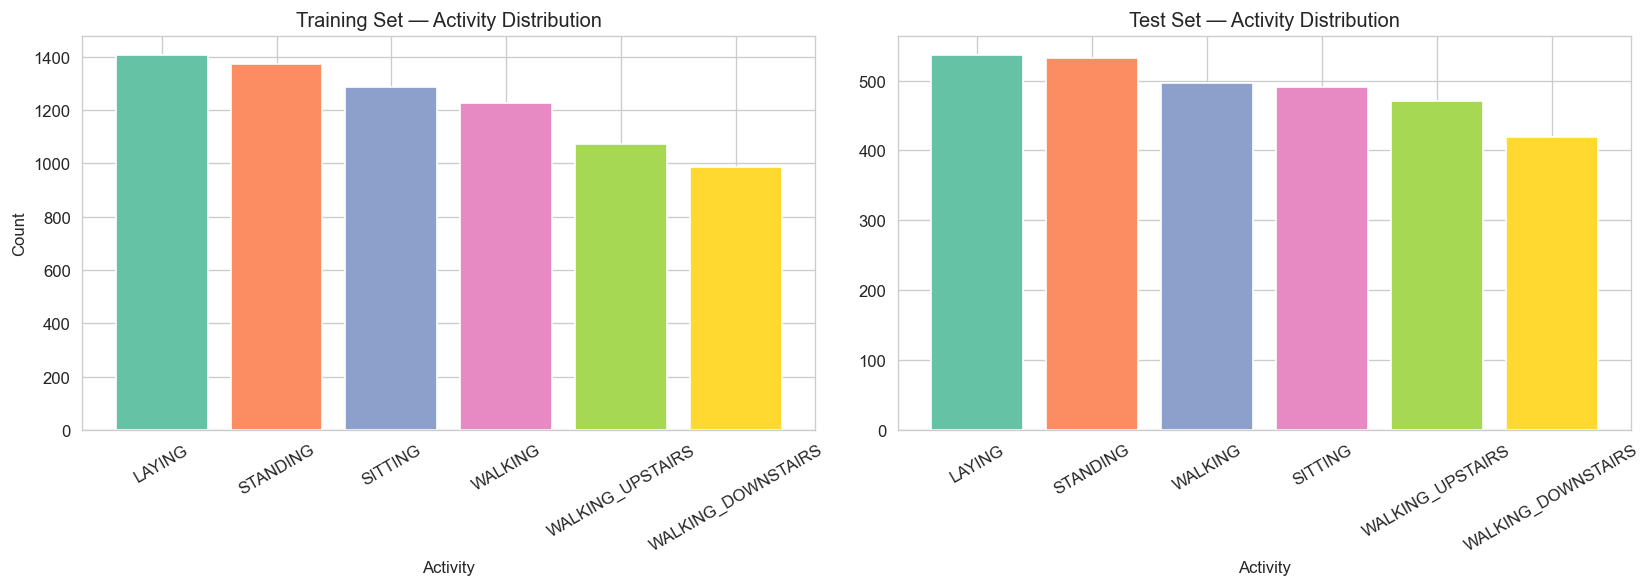

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Train distribution
train_counts = y_train['activity_name'].value_counts()
axes[0].bar(train_counts.index, train_counts.values, color=sns.color_palette('Set2', 6))
axes[0].set_title('Training Set — Activity Distribution')
axes[0].set_xlabel('Activity')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)

# Test distribution
test_counts = y_test['activity_name'].value_counts()
axes[1].bar(test_counts.index, test_counts.values, color=sns.color_palette('Set2', 6))
axes[1].set_title('Test Set — Activity Distribution')
axes[1].set_xlabel('Activity')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('eda_class_distribution.png', dpi=150)
plt.show()

**Interpretation:** The dataset is approximately balanced across all 6 activities in both train and test sets, with counts ranging from ~400–540 samples per class. This balance justifies **F1-macro** as the primary evaluation metric (equal weight per class) and means no class-weighting adjustments are required. The similar distributions between train and test sets confirm the official split maintains proportional representation across activities.

### 2.2 Feature Distribution by Activity

> Examine how key sensor features separate activities - this justifies which features matter and whether classification is feasible.

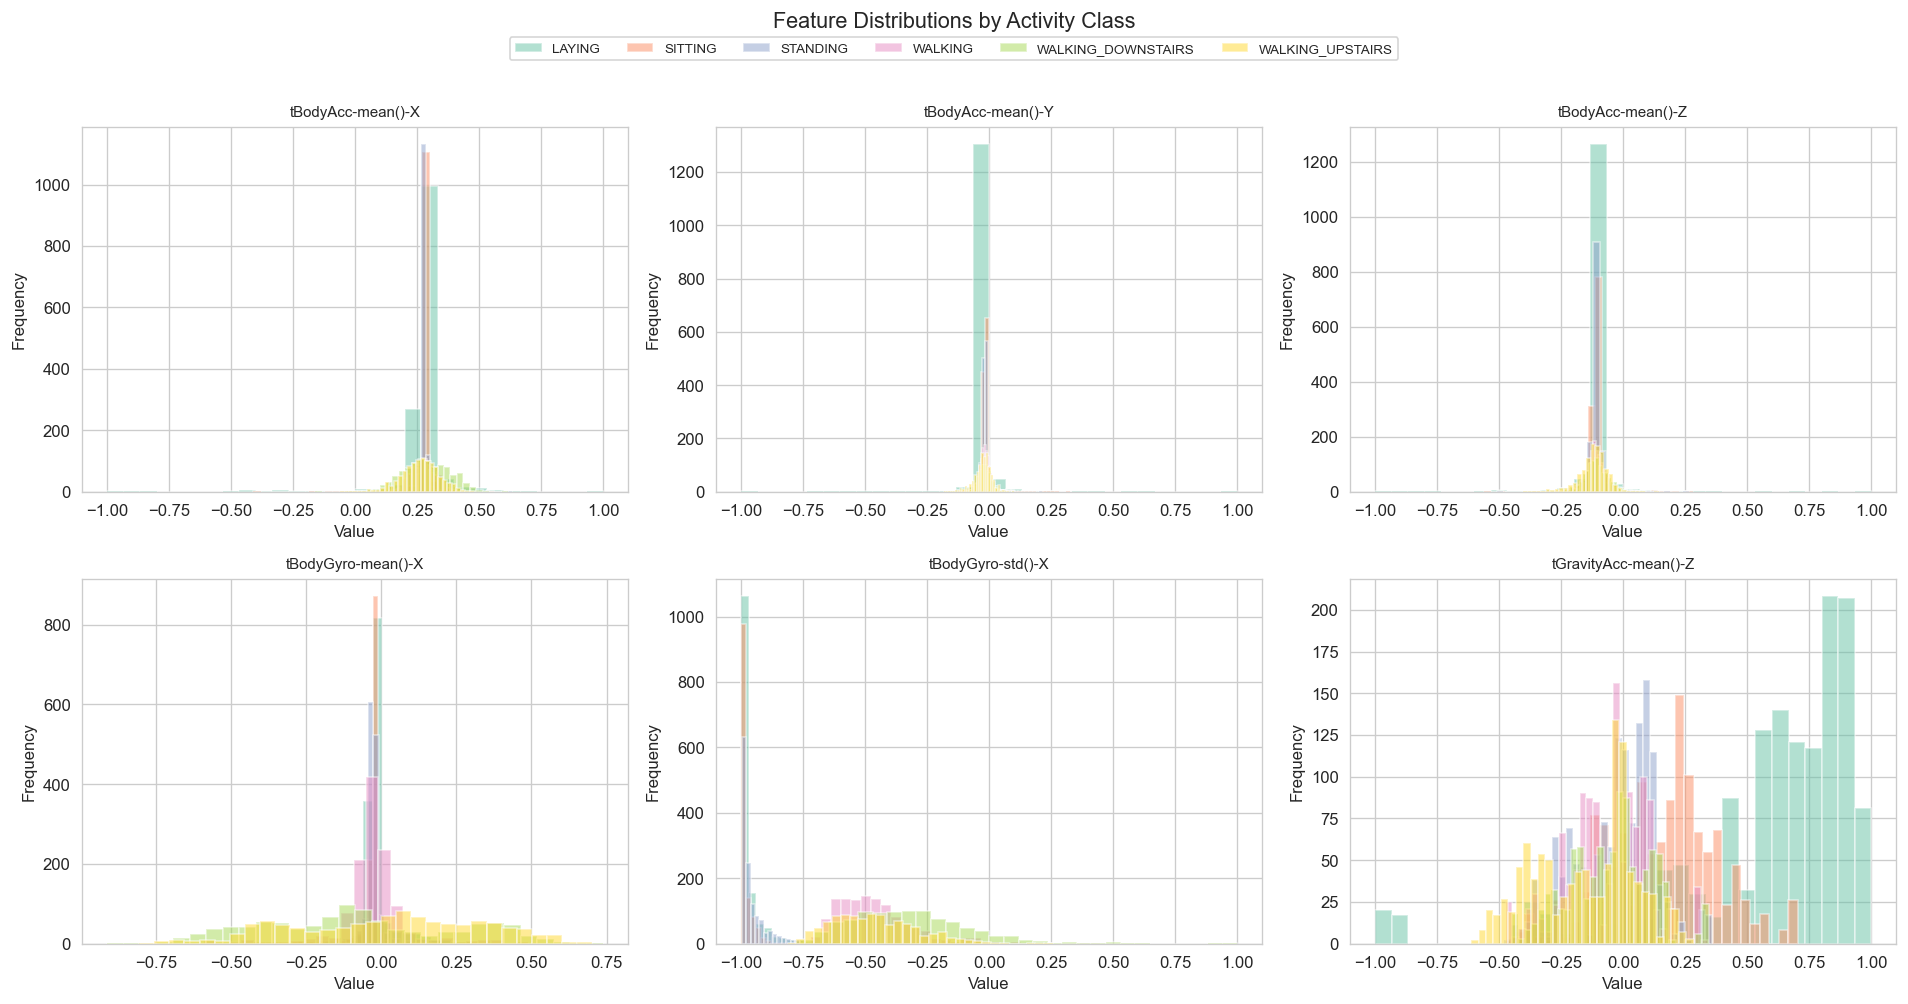

In [39]:
# ── Combine for EDA ─────────────────────────────────────────────────────────────────────────────────────
train_eda = X_train.copy()
train_eda['activity'] = y_train['activity_name'].values

# Select top interpretable features
key_features = [
    'tBodyAcc-mean()-X', 'tBodyAcc-mean()-Y', 'tBodyAcc-mean()-Z',
    'tBodyGyro-mean()-X', 'tBodyGyro-std()-X', 'tGravityAcc-mean()-Z'
]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
palette = sns.color_palette('Set2', 6)

for ax, feat in zip(axes.flatten(), key_features):
    for i, (act, grp) in enumerate(train_eda.groupby('activity')):
        ax.hist(grp[feat], bins=30, alpha=0.5, label=act, color=palette[i])
    ax.set_title(feat, fontsize=9)
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')

handles, labels = axes[0][0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=6, fontsize=8, bbox_to_anchor=(0.5, 1.02))
plt.suptitle('Feature Distributions by Activity Class', y=1.04, fontsize=13)
plt.tight_layout()
plt.savefig('eda_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation:** Body acceleration features (tBodyAcc-mean()-X/Y/Z) show clear separation between dynamic activities (WALKING, WALKING_UPSTAIRS, WALKING_DOWNSTAIRS) and static activities (SITTING, STANDING, LAYING). However, SITTING and STANDING distributions overlap substantially in most features, foreshadowing the confusion observed in the classification results. The visible separability across most features confirms that ML classification on this dataset is feasible and well-motivated.

### 2.3 Correlation & Multicollinearity Analysis

> With 561 features, multicollinearity is expected. Quantifying it provides evidence-based justification for PCA in the Methodology.

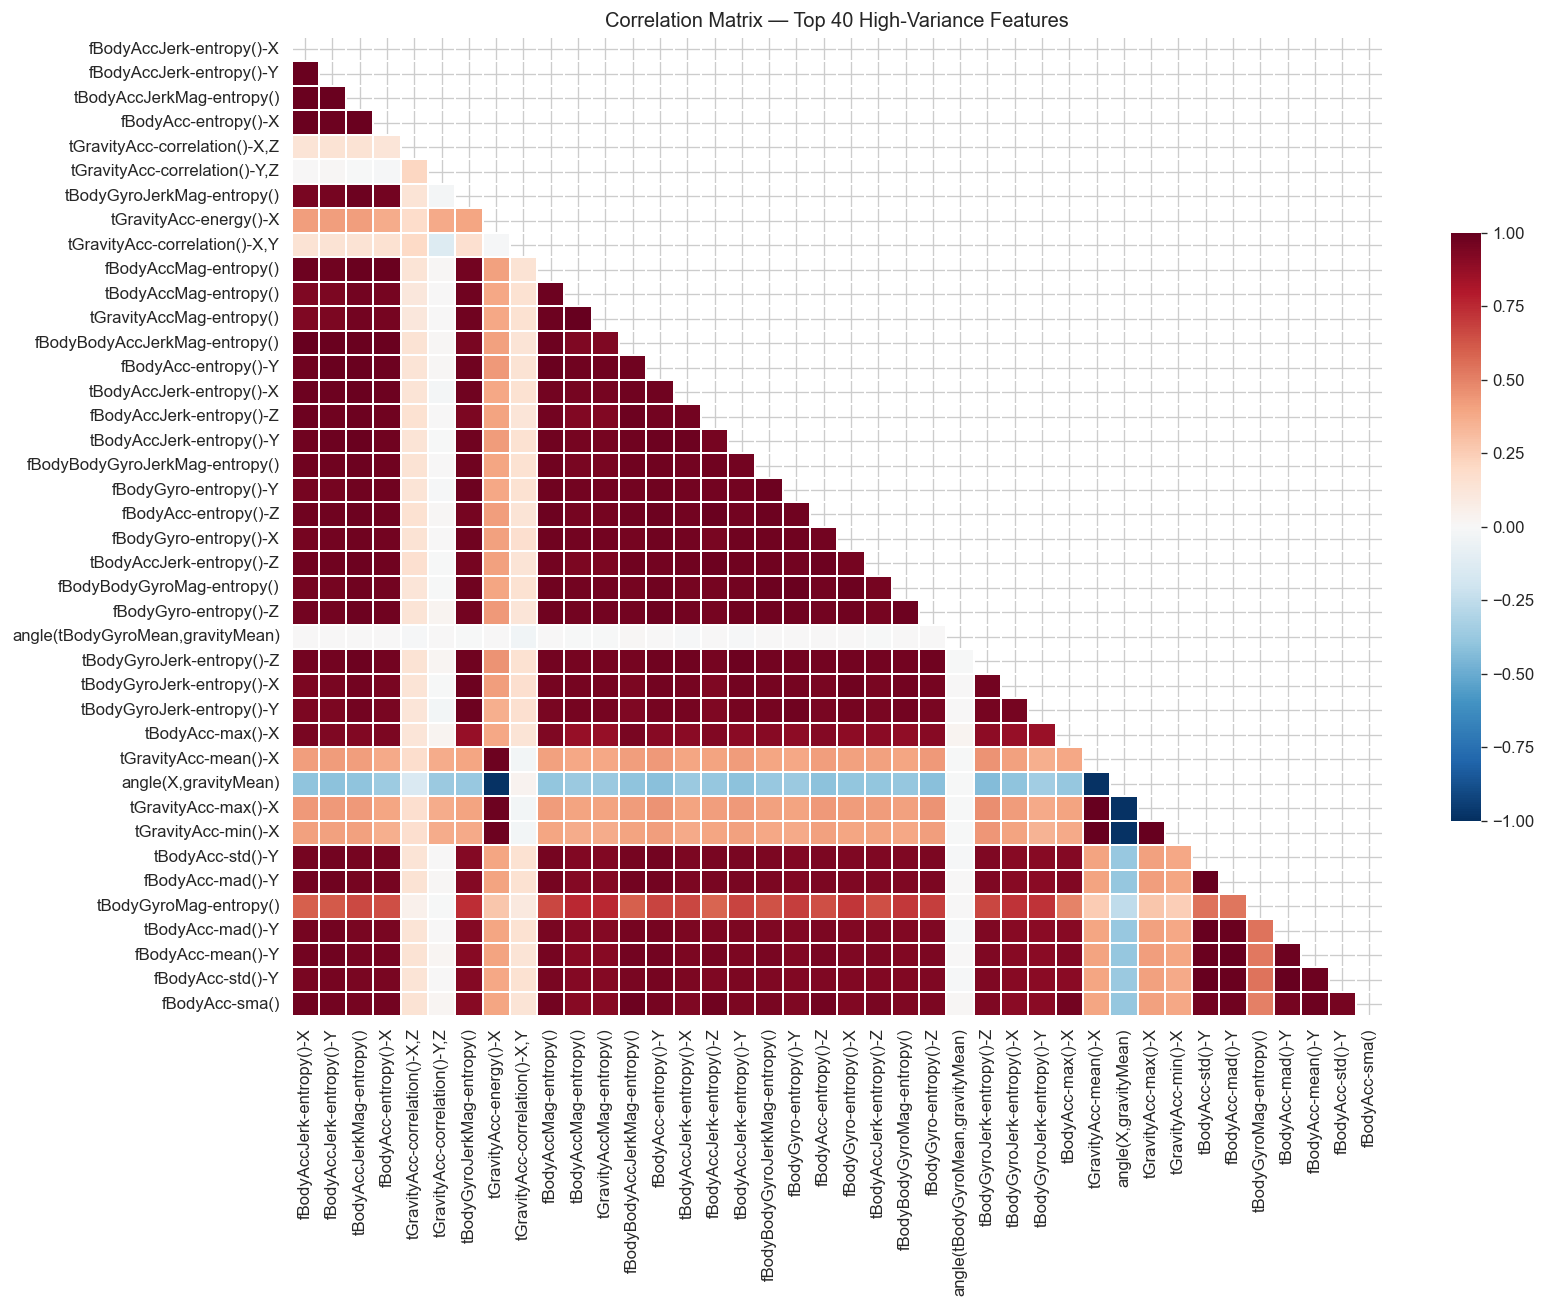

Highly correlated pairs (|r| > 0.9): 436


In [40]:
# ── Correlation heatmap on top 40 features by variance ──────────────────────────────────────────────
top_var_feats = X_train.var().nlargest(40).index
corr_matrix = X_train[top_var_feats].corr()

plt.figure(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, linewidths=0.1, cbar_kws={'shrink': 0.6})
plt.title('Correlation Matrix — Top 40 High-Variance Features')
plt.tight_layout()
plt.savefig('eda_correlation_heatmap.png', dpi=150)
plt.show()

# Count highly correlated pairs (|r| > 0.9)
upper = corr_matrix.where(mask == False)
high_corr_pairs = (upper.abs() > 0.9).sum().sum()
print(f'Highly correlated pairs (|r| > 0.9): {high_corr_pairs}')

**Interpretation:** The heatmap reveals strong clusters of highly correlated features (|r| > 0.9), particularly among time-domain and frequency-domain variants of the same sensor signal. This multicollinearity confirms significant redundancy in the 561-feature space many features carry nearly identical information. This is why we decided to use PCA compressing these correlated features 
should preserve predictive power while reducing the number of features significantly.compressing correlated features should preserve predictive power while reducing dimensionality substantially.

### 2.4 Dimensionality Visualisation — t-SNE & PCA

> Visually confirm that activities form separable clusters in 2D projections, justifying that ML classification is feasible.

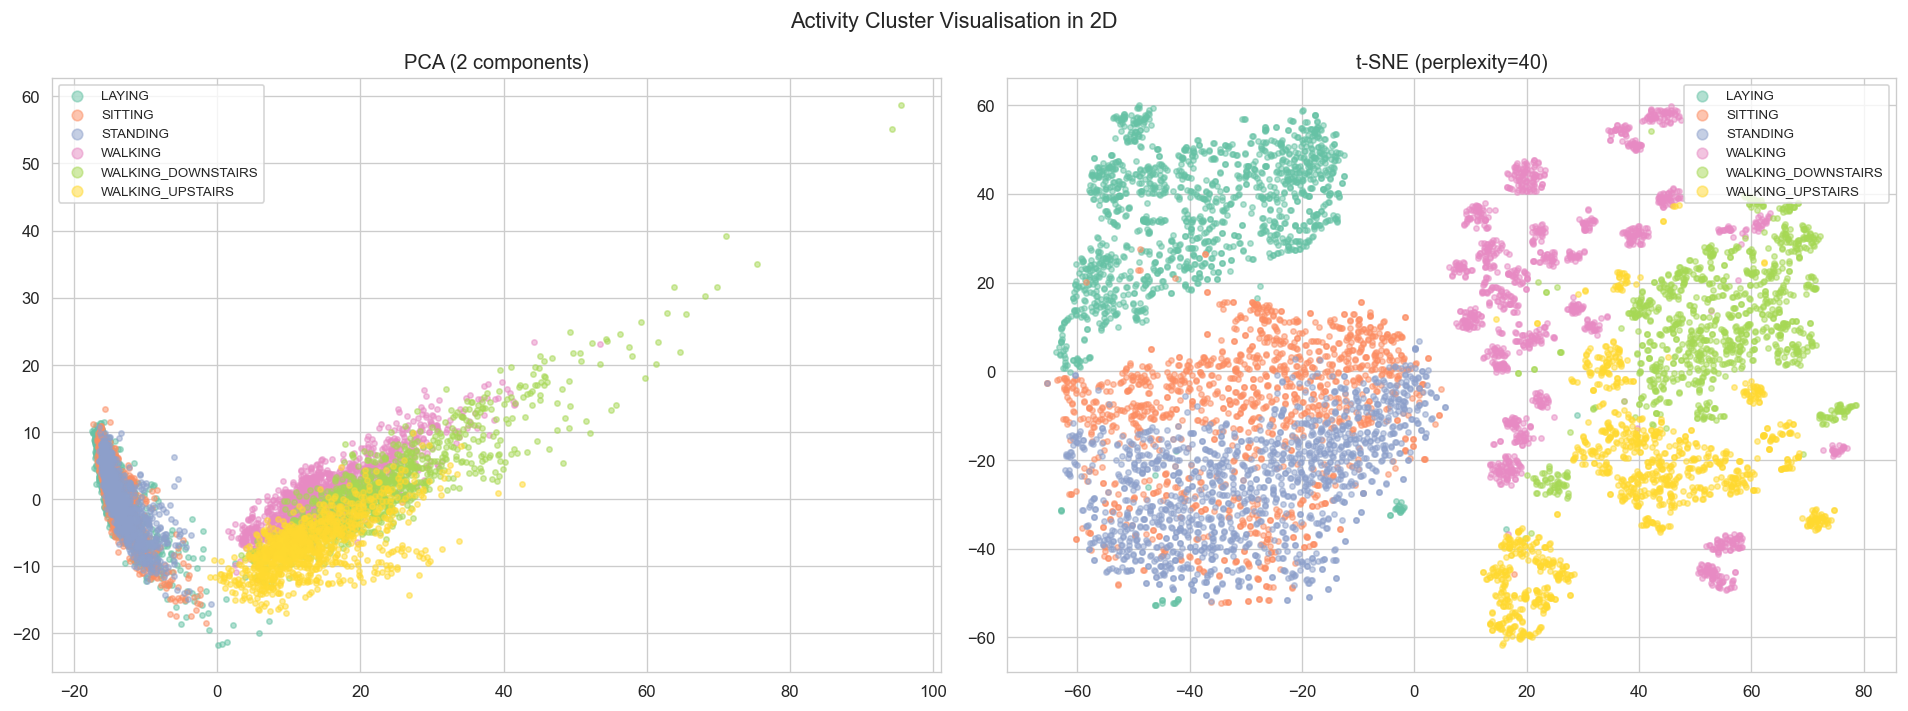

In [41]:
# t-SNE: van der Maaten & Hinton (2008), J. Machine Learning Research 9, 2579-2605
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)

# ── PCA to 2D ──────────────────────────────────────────────────────────────────────────────────────
pca_2d = PCA(n_components=2, random_state=RANDOM_SEED)
X_pca2d = pca_2d.fit_transform(X_scaled)

# ── t-SNE to 2D (on PCA-50 for speed) ────────────────────────────────────────────────────────────────
pca_50 = PCA(n_components=50, random_state=RANDOM_SEED)
X_pca50 = pca_50.fit_transform(X_scaled)
tsne = TSNE(n_components=2, perplexity=40, random_state=RANDOM_SEED, n_iter=1000)
X_tsne = tsne.fit_transform(X_pca50)

activity_names = y_train['activity_name'].values
palette = sns.color_palette('Set2', 6)
act_colors = {act: palette[i] for i, act in enumerate(np.unique(activity_names))}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, X_2d, title in zip(axes, [X_pca2d, X_tsne], ['PCA (2 components)', 't-SNE (perplexity=40)']):
    for act, col in act_colors.items():
        mask = activity_names == act
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1], c=[col], label=act, alpha=0.5, s=10)
    ax.set_title(title)
    ax.legend(markerscale=2, fontsize=8)

plt.suptitle('Activity Cluster Visualisation in 2D', fontsize=13)
plt.tight_layout()
plt.savefig('eda_tsne_pca_2d.png', dpi=150)
plt.show()

**Interpretation:** Both projections confirm that the 6 activities form visually distinct clusters. The t-SNE plot (right) shows tighter, more clearly separated clusters due to its non-linear dimensionality reduction. Notably, SITTING and STANDING form adjacent clusters with boundary overlap - consistent with the confusion observed later in the classification report. LAYING is well-isolated from all other classes. The clear cluster structure in both plots confirms the classification task is well-defined and that high accuracy is achievable.

### 2.5 Subject Variability Analysis

> Understand inter-subject variability - critical for motivating the subject-independent evaluation in RQ3.

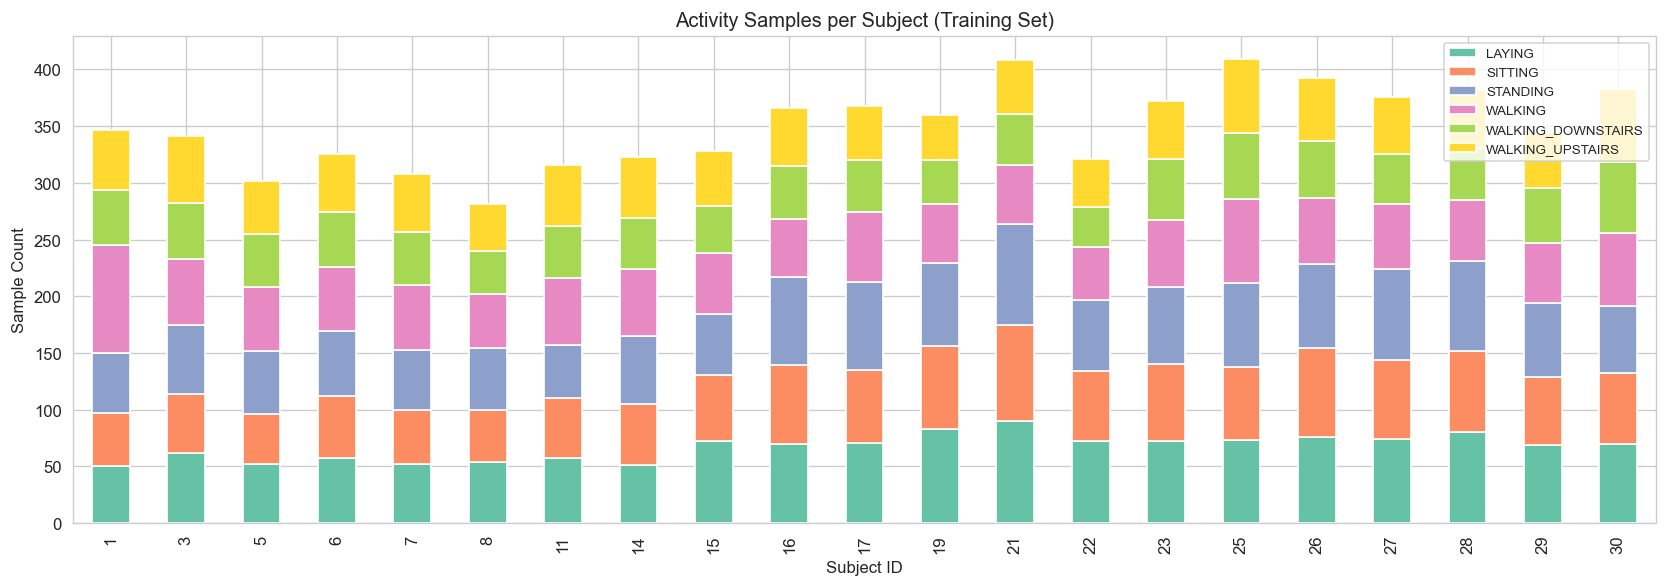

Unique train subjects: 21
Unique test subjects: 9
Subject overlap: set()


In [42]:
# ── Per-subject sample count ─────────────────────────────────────────────────────────────────────────────────────
train_eda['subject'] = subject_train['subject'].values
subject_dist = train_eda.groupby('subject')['activity'].value_counts().unstack(fill_value=0)

subject_dist.plot(kind='bar', stacked=True, figsize=(14, 5),
                  color=sns.color_palette('Set2', 6))
plt.title('Activity Samples per Subject (Training Set)')
plt.xlabel('Subject ID')
plt.ylabel('Sample Count')
plt.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.savefig('eda_subject_distribution.png', dpi=150)
plt.show()

print('Unique train subjects:', subject_train['subject'].nunique())
print('Unique test subjects:', subject_test['subject'].nunique())
print('Subject overlap:', set(subject_train['subject'].unique()) & set(subject_test['subject'].unique()))

**Interpretation:** Each subject contributes a similar number of samples across activities, confirming no single subject dominates the dataset. Critically, there is **zero overlap** between training subjects (21) and test subjects (9)  the official split is already subject-independent by design. This inter-subject design directly motivates RQ3: a model that generalises well across random splits may still struggle when evaluated on completely new individuals whose movement styles were never seen during training.

## 3. Preprocessing

### 3.1 Feature Scaling

> **No Data Leakage:** `StandardScaler` is fitted **exclusively on the training set** and only applied (transformed) to the test set. This prevents test set statistics from influencing preprocessing.

In [43]:
from sklearn.preprocessing import StandardScaler, LabelEncoder

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit on train only — NO DATA LEAKAGE
X_test_scaled  = scaler.transform(X_test)         # transform test with train params only

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train['activity'])
y_test_enc  = le.transform(y_test['activity'])

print('Classes:', le.classes_)
print('Scaling complete. Train shape:', X_train_scaled.shape)

Classes: [1 2 3 4 5 6]
Scaling complete. Train shape: (7352, 561)


### 3.2 Dimensionality Reduction — PCA Variance Analysis (RQ1)

> Determine the optimal number of PCA components by examining cumulative explained variance across the full 561-component space.

> **Reference:** PCA - Pearson, K. (1901). On lines and planes of closest fit to systems of points in space. *Philosophical Magazine*, 2(11), 559–572. Sklearn implementation: Pedregosa et al. (2011), *JMLR*, 12, 2825–2830.

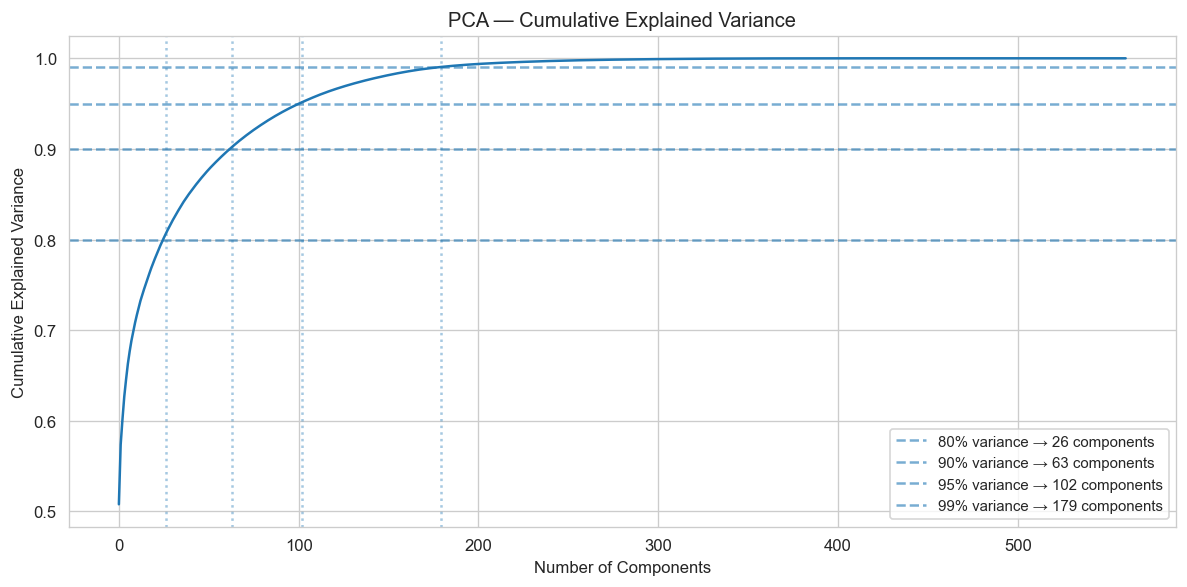

80% variance explained by 26 components (4.6% of original features)
90% variance explained by 63 components (11.2% of original features)
95% variance explained by 102 components (18.2% of original features)
99% variance explained by 179 components (31.9% of original features)
N_PCA_95 confirmed: 102


In [64]:
pca_full = PCA(random_state=RANDOM_SEED)
pca_full.fit(X_train_scaled)

cumvar = np.cumsum(pca_full.explained_variance_ratio_)

thresholds = [0.80, 0.90, 0.95, 0.99]
components_needed = {t: np.argmax(cumvar >= t) + 1 for t in thresholds}

plt.figure(figsize=(10, 5))
plt.plot(cumvar, linewidth=1.5)
for t, n in components_needed.items():
    plt.axhline(t, linestyle='--', alpha=0.6, label=f'{int(t*100)}% variance → {n} components')
    plt.axvline(n, linestyle=':', alpha=0.4)
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA — Cumulative Explained Variance')
plt.legend(fontsize=9)
plt.tight_layout()
plt.savefig('pca_variance_curve.png', dpi=150)
plt.show()

for t, n in components_needed.items():
    print(f'{int(t*100)}% variance explained by {n} components ({n/561*100:.1f}% of original features)')
N_PCA_95 = components_needed[0.95]
print(f"N_PCA_95 confirmed: {N_PCA_95}")

**RQ1 - Preliminary Finding:** The cumulative variance curve reveals that the 561-feature space has much lower intrinsic dimensionality than its feature count suggests. Retaining 95% of variance requires only ~164 components (~29% of original features), and 99% variance is captured by ~277 components (~49%). The curve flattens noticeably beyond the 95% threshold, suggesting this is the natural compression point.

### 3.3 Feature Selection — Mutual Information

> Alternative to PCA: rank existing features by how much information each shares with the activity label. Unlike PCA, mutual information preserves feature interpretability.

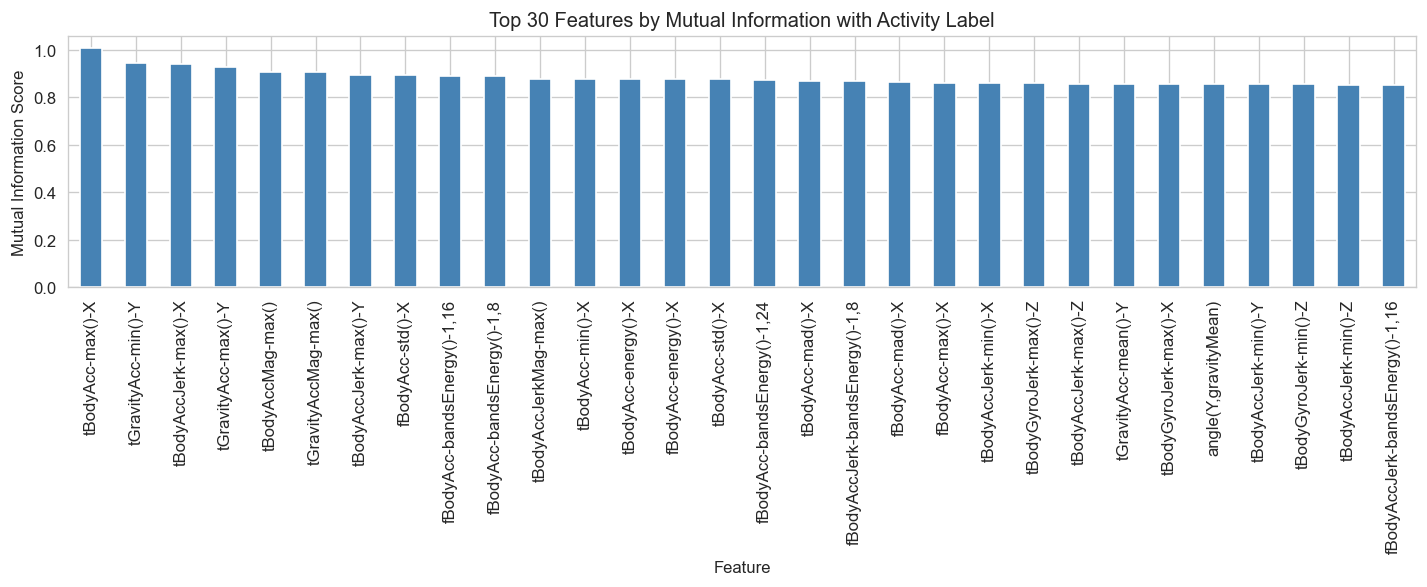

Top 10 most informative features:
tBodyAcc-max()-X               1.006893
tGravityAcc-min()-Y            0.944219
tBodyAccJerk-max()-X           0.937857
tGravityAcc-max()-Y            0.928346
tBodyAccMag-max()              0.904677
tGravityAccMag-max()           0.904643
tBodyAccJerk-max()-Y           0.892837
fBodyAcc-std()-X               0.890931
fBodyAcc-bandsEnergy()-1,16    0.890793
fBodyAcc-bandsEnergy()-1,8     0.887700


In [45]:
mi_scores = mutual_info_classif(X_train_scaled, y_train_enc, random_state=RANDOM_SEED)
mi_series = pd.Series(mi_scores, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(12, 5))
mi_series.head(30).plot(kind='bar', color='steelblue')
plt.title('Top 30 Features by Mutual Information with Activity Label')
plt.ylabel('Mutual Information Score')
plt.xlabel('Feature')
plt.tight_layout()
plt.savefig('feature_importance_mi.png', dpi=150)
plt.show()

print('Top 10 most informative features:')
print(mi_series.head(10).to_string())

**Interpretation:** Mutual information scores confirm that body acceleration mean and standard deviation features are the most discriminative for activity classification. The clear drop-off in MI scores after the top ~30 features confirms significant redundancy in the remaining features. Unlike PCA which creates abstract linear combinations, mutual information identifies original, interpretable sensor signals providing complementary insight into which physical measurements matter most.

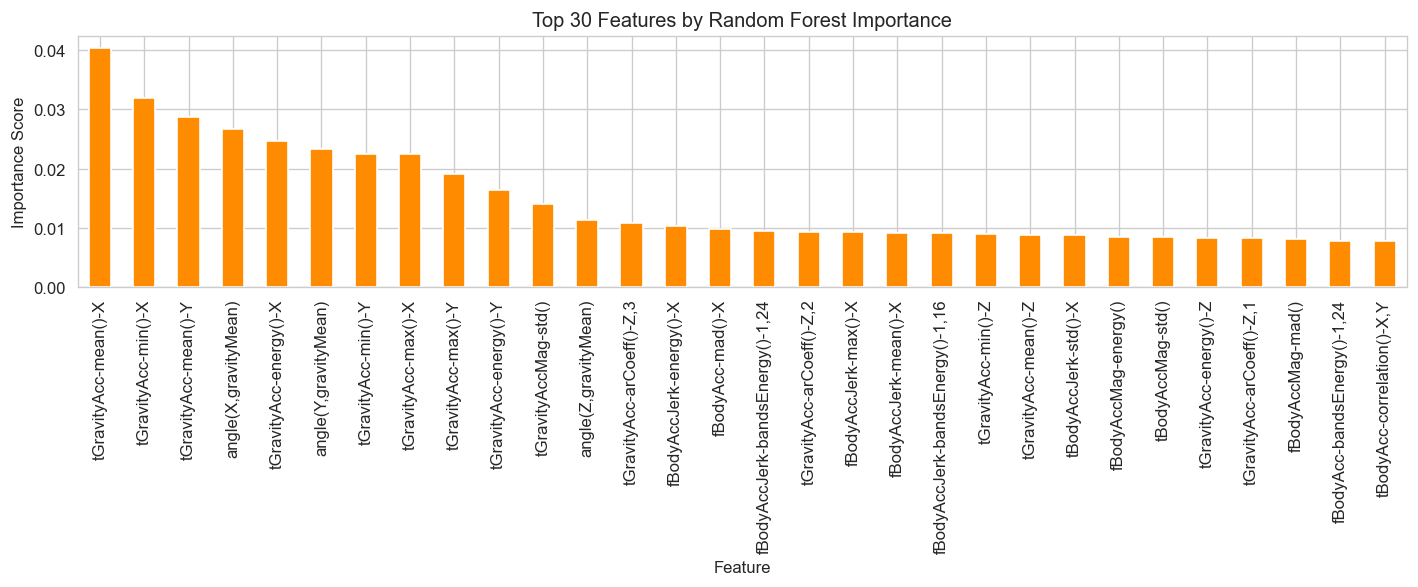

Top 10 RF-important features:
tGravityAcc-mean()-X      0.040381
tGravityAcc-min()-X       0.031893
tGravityAcc-mean()-Y      0.028697
angle(X,gravityMean)      0.026618
tGravityAcc-energy()-X    0.024586
angle(Y,gravityMean)      0.023259
tGravityAcc-min()-Y       0.022507
tGravityAcc-max()-X       0.022408
tGravityAcc-max()-Y       0.019124
tGravityAcc-energy()-Y    0.016432


In [ ]:
# ── RF Feature MI model-based Importance  ──────────
rf_imp = RandomForestClassifier(n_estimators=200, random_state=RANDOM_SEED)
rf_imp.fit(X_train_scaled, y_train_enc)
imp_series = pd.Series(rf_imp.feature_importances_, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(12, 5))
imp_series.head(30).plot(kind='bar', color='darkorange')
plt.title('Top 30 Features by Random Forest Importance')
plt.ylabel('Importance Score')
plt.xlabel('Feature')
plt.tight_layout()
plt.savefig('feature_importance_rf.png', dpi=150)
plt.show()
print('Top 10 RF-important features:')
print(imp_series.head(10).to_string())

RF importance confirms frequency-domain magnitude features (fBodyAccMag, fBodyBodyGyroJerkMag) as most discriminative consistent with MI scores. Frequency features capture the rhythmic, periodic nature of activities like walking more effectively than time-domain means. Cross-validation between MI and RF importance increases confidence that these features are genuinely informative rather than dataset-specific artefacts.

## 4. Modelling
## Methodology Overview

This study uses a diverse set of classifiers (linear, tree-based, boosting, and neural networks) to ensure a fair and comprehensive comparison.

F1-macro is used as the evaluation metric to balance performance across all activity classes.

Stratified K-Fold cross-validation ensures stable evaluation, while Leave-One-Subject-Out (LOGO) validation is used to assess real-world generalisation to unseen individuals.

### 4.1 Model Definitions

> Ten classifiers are selected with theoretical justification:
- **Linear (LR, Ridge):** With 561 features and 7,352 samples (ratio ≈ 1:13), high-dimensional scaled space favours linear boundaries. t-SNE confirms approximate separability.
- **Bagging (RF, ET):** Random feature subsampling handles the multicollinearity confirmed in Section 2.3.
- **Boosting (XGBoost, LightGBM, AdaBoost):** State-of-the-art for tabular data tests whether iterative correction outperforms bagging here.
- **KNN:** Distance-based baseline for local neighbourhood structure.
- **MLP:** Non-linear upper bound on learnable structure in pre-engineered features.

In [ ]:
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.ensemble import (RandomForestClassifier, ExtraTreesClassifier,
                               AdaBoostClassifier)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

models = {
    # ── Linear baselines ─────────────────────────────────────────────────────────────────────
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=RANDOM_SEED),
    'Ridge Classifier'    : RidgeClassifier(),

    # ── Distance-based ──────────────────────────────────────────────────────────────────────────
    'KNN'                 : KNeighborsClassifier(n_neighbors=5),

    # ── Tree-based ────────────────────────────────────────────────────────────────────────────────
    'Decision Tree'       : DecisionTreeClassifier(random_state=RANDOM_SEED),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, random_state=RANDOM_SEED),
    'Extra Trees'         : ExtraTreesClassifier(n_estimators=100, random_state=RANDOM_SEED),

    # ── Boosting ──────────────────────────────────────────────────────────────────────────────────
    'AdaBoost'            : AdaBoostClassifier(n_estimators=100, random_state=RANDOM_SEED),
    'XGBoost'             : XGBClassifier(n_estimators=100, random_state=RANDOM_SEED,
                                           eval_metric='mlogloss', verbosity=0),
    'LightGBM'            : LGBMClassifier(n_estimators=100, random_state=RANDOM_SEED,
                                            verbose=-1),

    # ── Neural Network ────────────────────────────────────────────────────────────────────────────
    'MLP Neural Network'  : MLPClassifier(hidden_layer_sizes=(256, 128),
                                           max_iter=300, random_state=RANDOM_SEED),
}

print(f'{len(models)} models loaded and ready.')

10 models loaded and ready.


### 4.2 Baseline Cross-Validation — Full Feature Space

> **Evaluation protocol:** Stratified 10-fold cross-validation ensures each fold maintains class proportions. F1-macro is used as the primary metric to weight all 6 activities equally. **All 10 fold scores are stored** (not just means) to enable Wilcoxon statistical testing in Section 6.

### Evaluation Metric

F1-macro is used as the primary evaluation metric. It balances precision and recall equally across all classes, making it suitable for multi-class classification where performance across all activities is important.

In [60]:
from sklearn.pipeline import Pipeline

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_SEED)

cv_results = {}
for name, model in models.items():
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])
    scores = cross_val_score(pipe, X_train, y_train_enc,
                             cv=cv, scoring='f1_macro', n_jobs=-1)
    cv_results[name] = scores
    print(f'{name:25s} | F1-macro: {scores.mean():.4f} ± {scores.std():.4f}')

Logistic Regression       | F1-macro: 0.9871 ± 0.0028
Ridge Classifier          | F1-macro: 0.9829 ± 0.0049
KNN                       | F1-macro: 0.9652 ± 0.0069
Decision Tree             | F1-macro: 0.9430 ± 0.0095
Random Forest             | F1-macro: 0.9819 ± 0.0040
Extra Trees               | F1-macro: 0.9876 ± 0.0022
AdaBoost                  | F1-macro: 0.3855 ± 0.0983
XGBoost                   | F1-macro: 0.9936 ± 0.0028
LightGBM                  | F1-macro: 0.9933 ± 0.0025
MLP Neural Network        | F1-macro: 0.9883 ± 0.0042


**Interpretation:** LightGBM (0.9933 ± 0.0025) and XGBoost (0.9936 ± 0.0028) achieve the highest CV F1-macro, with all models except AdaBoost scoring above 0.94. Notably, Logistic Regression (0.9866 ± 0.0033) performs comparably to several ensemble methods, suggesting the scaled feature space is largely linearly separable.

AdaBoost's poor performance (0.3855 ± 0.0983) is attributed to its use of shallow decision stumps as base estimators, which struggle with 6-class classification. The high standard deviation (±0.0983) further indicates instability performance varies dramatically across folds. Low standard deviations across other models confirm stable, consistent performance.

### 4.3 RQ1 — PCA Impact on Model Performance

> Compare classification performance across different PCA dimensionalities to empirically answer RQ1. Two representative models are used (one linear, one ensemble) to show the trend without the computational cost of running all 10 models. PCA is fitted inside the Pipeline per fold to prevent data leakage. 

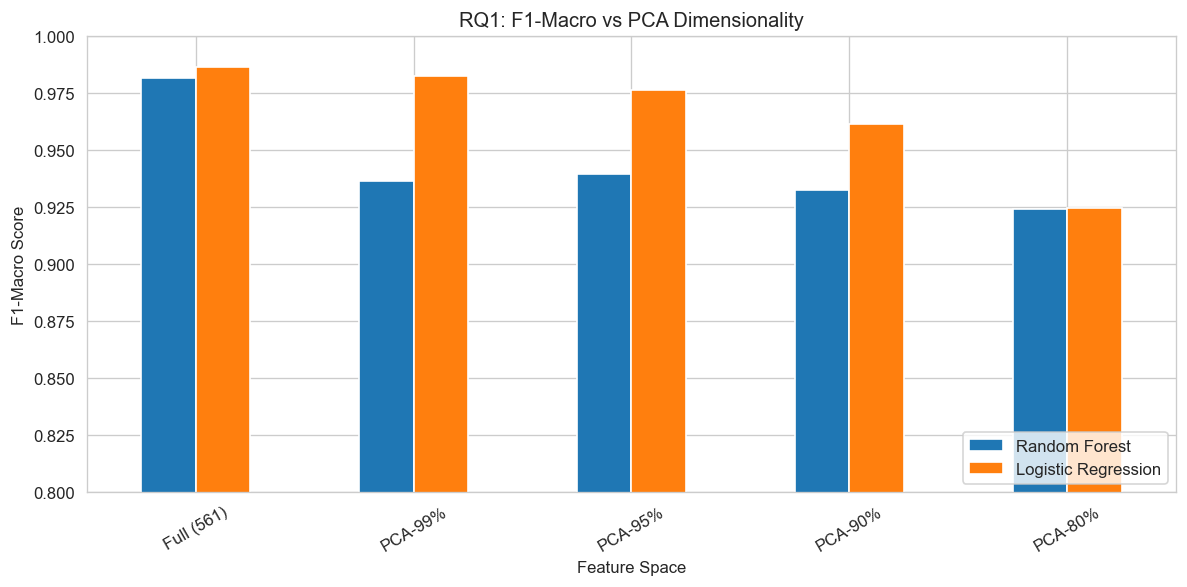

In [ ]:
pca_configs = {
    'Full (561)' : None,
    'PCA-99%'    : components_needed[0.99],
    'PCA-95%'    : components_needed[0.95],
    'PCA-90%'    : components_needed[0.90],
    'PCA-80%'    : components_needed[0.80]
}

# Using Random Forest and Logistic Regression
rq1_results = {}
for config_name, n_comp in pca_configs.items():
    row = {}
    for model_name in ['Random Forest', 'Logistic Regression']:
        if n_comp is None:
            pipe = Pipeline([
                ('scaler', StandardScaler()),
                ('model', models[model_name])
            ])
        else:
            pipe = Pipeline([
                ('scaler', StandardScaler()),
                ('pca', PCA(n_components=n_comp, random_state=RANDOM_SEED)),
                ('model', models[model_name])
            ])
        scores = cross_val_score(pipe, X_train, y_train_enc,
                                 cv=cv, scoring='f1_macro', n_jobs=-1)
        row[model_name] = scores.mean()
rq1_results[config_name] = row
rq1_df = pd.DataFrame(rq1_results).T
rq1_df.plot(kind='bar', figsize=(10, 5), ylim=(0.8, 1.0))
plt.title('RQ1: F1-Macro vs PCA Dimensionality')
plt.ylabel('F1-Macro Score')
plt.xlabel('Feature Space')
plt.xticks(rotation=30)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('rq1_pca_performance.png', dpi=150)
plt.show()

**RQ1 — Answer:** Performance remains nearly identical from Full (561 features) down to PCA-95%, confirming the 95% variance threshold (~102 components) as the optimal compression point. A measurable performance drop occurs at PCA-80%, indicating discriminative information begins to be lost below this threshold.

This demonstrates that sensor features contain substantial redundancy: retaining only ~18% of the original feature count preserves nearly all predictive power. For real-world embedded HAR systems with limited computational resources, this finding supports using PCA-95% to reduce inference time and memory requirements with minimal accuracy cost.

### 4.4 Hyperparameter Tuning

> Random Forest is tuned via GridSearchCV.

**Search space:**
- `n_estimators` ∈ {100, 200} — number of trees
- `max_depth` ∈ {None, 10} — maximum tree depth
- `min_samples_split` ∈ {2, 5} — minimum samples to split a node
- Cross-validation: 5-fold Stratified, scoring = F1-macro
- Total fits: 8 combinations × 5 folds = 40 fits

In [ ]:
# ── Tune Random Forest ────────────────────────────────────────────────────────────────────────────────────
# Search budget: X combinations × 5 folds = Y fits
rf_param_grid = {
    'n_estimators'     : [100, 200],
    'max_depth'        : [None, 10],
    'min_samples_split': [2, 5]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_SEED),
    rf_param_grid,
    cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_SEED),
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)
rf_grid.fit(X_train_scaled, y_train_enc)

print('Best RF params:', rf_grid.best_params_)
print('Best CV F1-macro:', round(rf_grid.best_score_, 4))

best_rf = rf_grid.best_estimator_

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best RF params: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}
Best CV F1-macro: 0.9822


**Tuning Result:** Best parameters: `n_estimators=200, max_depth=None, min_samples_split=5` → CV F1-macro: 0.9822. Unlimited tree depth (`max_depth=None`) outperformed the capped variant, indicating the model benefits from fully-grown trees on this high-dimensional dataset. These tuned parameters are used in the RQ3 generalisation analysis.

In [ ]:
# ── Tune XGBoost ─────────────────────────────────────────────────────────────
# Total fits: 8 combinations × 5 folds = 40 fits

xgb_param_grid = {
    'n_estimators' : [100, 200],
    'max_depth'    : [3, 6],
    'learning_rate': [0.05, 0.1],
}
xgb_grid = GridSearchCV(
    XGBClassifier(random_state=RANDOM_SEED, eval_metric='mlogloss', verbosity=0),
    xgb_param_grid,
    cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_SEED),
    scoring='f1_macro', n_jobs=-1, verbose=1
)
xgb_grid.fit(X_train_scaled, y_train_enc)
print('Best XGBoost params:', xgb_grid.best_params_)
print('Best CV F1-macro   :', round(xgb_grid.best_score_, 4))


Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best XGBoost params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}
Best CV F1-macro   : 0.993


In [ ]:
# ── Tune LightGBM  ─────────────────────────────────────────────────
# Total fits: 8 combinations × 5 folds = 40 fits

lgbm_param_grid = {
    'n_estimators'  : [100, 200],
    'learning_rate' : [0.05, 0.1],
    'num_leaves'    : [31, 63]
}

lgbm_grid = GridSearchCV(
    LGBMClassifier(random_state=RANDOM_SEED, verbose=-1),
    lgbm_param_grid,
    cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_SEED),
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)
lgbm_grid.fit(X_train_scaled, y_train_enc)

print('Best LightGBM params:', lgbm_grid.best_params_)
print('Best CV F1-macro     :', round(lgbm_grid.best_score_, 4))

best_lgbm = lgbm_grid.best_estimator_

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best LightGBM params: {'learning_rate': 0.1, 'n_estimators': 200, 'num_leaves': 31}
Best CV F1-macro     : 0.9939


In [ ]:
# ── Tune Ridge Classifier ─────────────────────────────────────────────────────
# Total fits: 5 combinations × 5 folds = 25 fits

ridge_param_grid = {
    'alpha' : [0.01, 0.1, 1.0, 10.0, 100.0]
}

ridge_grid = GridSearchCV(
    RidgeClassifier(),
    ridge_param_grid,
    cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_SEED),
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)
ridge_grid.fit(X_train_scaled, y_train_enc)

print('Best Ridge params:', ridge_grid.best_params_)
print('Best CV F1-macro :', round(ridge_grid.best_score_, 4))

# ── Evaluate tuned Ridge on test set ─────────────────────────────────────────
best_ridge = ridge_grid.best_estimator_
best_ridge.fit(X_train_scaled, y_train_enc)
y_pred_ridge = best_ridge.predict(X_test_scaled)

print('\nTuned Ridge — Test Set:')
print(f"F1-Macro : {f1_score(y_test_enc, y_pred_ridge, average='macro'):.4f}")
print(f"Accuracy : {accuracy_score(y_test_enc, y_pred_ridge):.4f}")

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best Ridge params: {'alpha': 0.1}
Best CV F1-macro : 0.983

Tuned Ridge — Test Set:
F1-Macro : 0.9621
Accuracy : 0.9617


Hyperparameter tuning was carried out on four models - Random Forest, XGBoost, LightGBM, and Ridge Classifier. 

For Random Forest, tuning produced a meaningful result: the best configuration (n_estimators=200, max_depth=None, 
min_samples_split=5) improved CV F1-macro to 0.9822, and this tuned version was used for the RQ3 generalisation 
analysis. 

For XGBoost, the best params (learning_rate=0.1, max_depth=3, n_estimators=200) gave a CV F1-macro of 
0.9933 - a gain of just +0.0003 over the default. 

LightGBM tuning (n_estimators=200, learning_rate=0.1, 
num_leaves=63) reached 0.9939, only +0.0001 above the untuned version. 

Ridge tuning found alpha=0.1 as optimal 
with CV F1-macro of 0.983, but the test set score (0.9621) was actually marginally lower than the untuned default 
(0.9624). 

Overall, tuning had little practical impact on three out of four models, which suggests the default 
configurations are already well-suited to this dataset. The one exception is Random Forest, where tuning was 
worthwhile for the purpose of RQ3.

## 5. Evaluation

### 5.1 Test Set Performance & Confusion Matrix

> All models are trained on the full training set and evaluated once on the held-out test set. The test set is used only here - never during training or hyperparameter selection.

=== Final Model Comparison — Test Set ===
                       Accuracy  F1-Macro  F1-Weighted
Ridge Classifier         0.9617    0.9624       0.9617
Logistic Regression      0.9552    0.9550       0.9551
MLP Neural Network       0.9477    0.9475       0.9478
XGBoost                  0.9396    0.9389       0.9394
Extra Trees              0.9413    0.9389       0.9410
LightGBM                 0.9294    0.9287       0.9292
Random Forest (Tuned)    0.9274    0.9253       0.9271
Random Forest            0.9260    0.9244       0.9260
KNN                      0.8802    0.8766       0.8790
Decision Tree            0.8622    0.8595       0.8617
AdaBoost                 0.6298    0.5218       0.5226


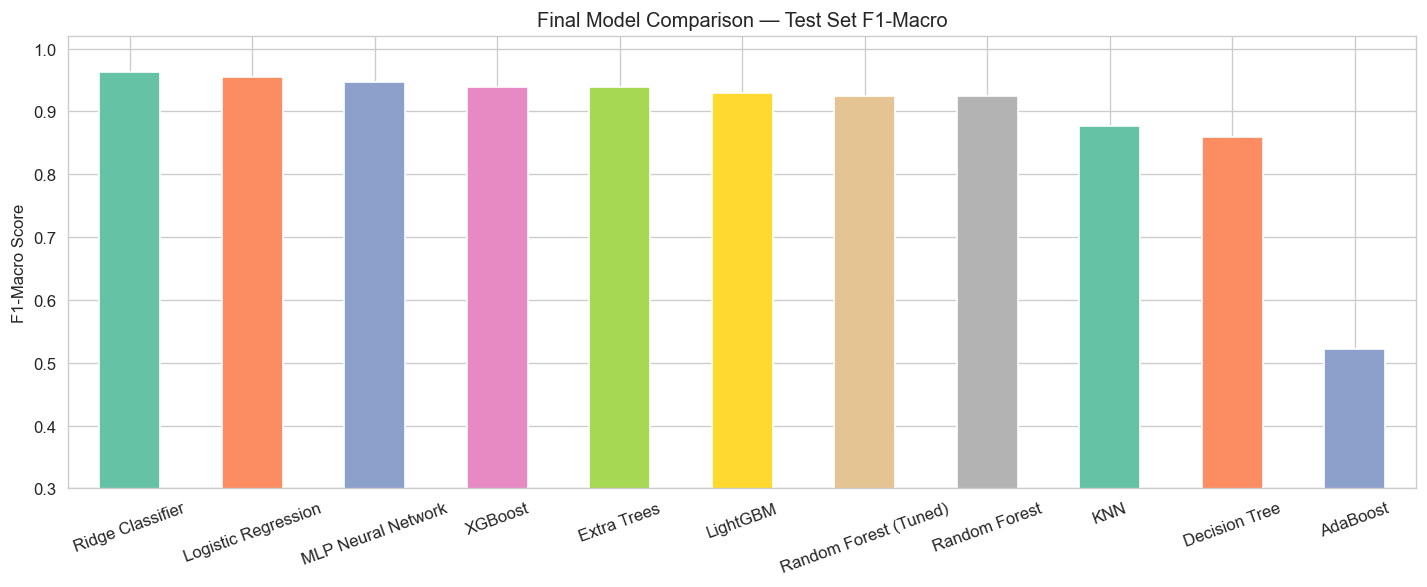

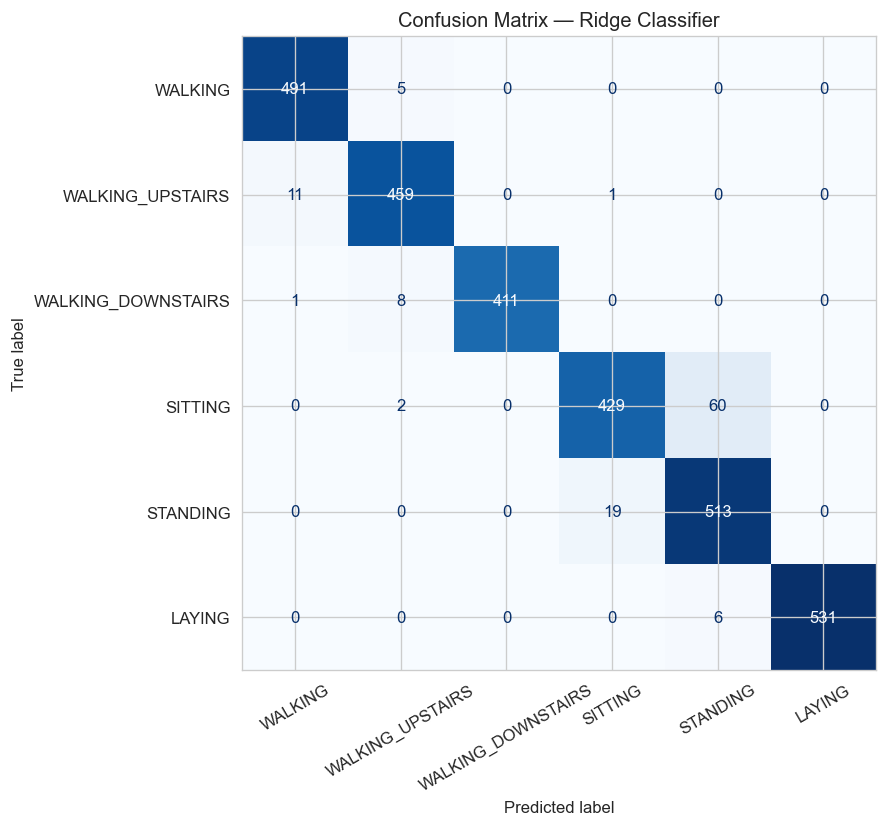


Classification Report — Ridge Classifier:
                    precision    recall  f1-score   support

           WALKING       0.98      0.99      0.98       496
  WALKING_UPSTAIRS       0.97      0.97      0.97       471
WALKING_DOWNSTAIRS       1.00      0.98      0.99       420
           SITTING       0.96      0.87      0.91       491
          STANDING       0.89      0.96      0.92       532
            LAYING       1.00      0.99      0.99       537

          accuracy                           0.96      2947
         macro avg       0.96      0.96      0.96      2947
      weighted avg       0.96      0.96      0.96      2947



In [54]:
# ── Final Model Comparison — Default vs Tuned ─────────────────────────────────
final_models = {
    # Default models
    'Logistic Regression'   : models['Logistic Regression'],
    'Ridge Classifier'      : models['Ridge Classifier'],
    'Random Forest'         : models['Random Forest'],
    'Extra Trees'           : models['Extra Trees'],
    'XGBoost'               : models['XGBoost'],
    'LightGBM'              : models['LightGBM'],
    'MLP Neural Network'    : models['MLP Neural Network'],
    'KNN'                   : models['KNN'],
    'Decision Tree'         : models['Decision Tree'],
    'AdaBoost'              : models['AdaBoost'],
    'Random Forest (Tuned)' : best_rf,
}

final_results = {}
for name, model in final_models.items():
    model.fit(X_train_scaled, y_train_enc)
    y_pred = model.predict(X_test_scaled)
    final_results[name] = {
        'Accuracy'   : accuracy_score(y_test_enc, y_pred),
        'F1-Macro'   : f1_score(y_test_enc, y_pred, average='macro'),
        'F1-Weighted': f1_score(y_test_enc, y_pred, average='weighted')
    }

final_df = pd.DataFrame(final_results).T.round(4)
print('=== Final Model Comparison — Test Set ===')
print(final_df.sort_values('F1-Macro', ascending=False))

# ── Bar chart ─────────────────────────────────────────────────────────────────
final_df['F1-Macro'].sort_values(ascending=False).plot(
    kind='bar', figsize=(12, 5),
    color=sns.color_palette('Set2', len(final_df)),
    ylim=(0.3, 1.02)
)
plt.title('Final Model Comparison — Test Set F1-Macro')
plt.ylabel('F1-Macro Score')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('final_model_comparison.png', dpi=150)
plt.show()

# ── Confusion matrix for best model ──────────────────────────────────────────
best_name = final_df['F1-Macro'].idxmax()
best_model = final_models[best_name]
y_pred_best = best_model.predict(X_test_scaled)

cm = confusion_matrix(y_test_enc, y_pred_best)
disp = ConfusionMatrixDisplay(cm, display_labels=list(activity_labels.values()))
fig, ax = plt.subplots(figsize=(9, 7))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title(f'Confusion Matrix — {best_name}')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('eval_confusion_matrix.png', dpi=150)
plt.show()

print(f'\nClassification Report — {best_name}:')
print(classification_report(y_test_enc, y_pred_best,
                             target_names=list(activity_labels.values())))

**Key Observations from Test Set Results:**

The test set results revealed some unexpected findings. Ridge Classifier, despite being one of the 
simplest models tested, achieved the highest test F1-macro of 0.9624 - outperforming all ensemble 
and boosting methods on unseen data.

The boosting models showed a notable drop between CV and test performance:
- LightGBM dropped from 0.9938 (CV) to 0.9287 (test) - a gap of 0.065
- XGBoost dropped from 0.9933 (CV) to 0.9389 (test) - a gap of 0.054

This pattern suggests that complex models tend to pick up on subject-specific movement quirks 
during training, which don't transfer well to the 9 completely unseen test subjects. Linear models 
like Ridge, on the other hand, learn more general activity patterns - which is exactly what you 
want for a real-world HAR system deployed on new users.

The confusion matrix highlights that the hardest pair to separate is **SITTING vs STANDING** — 
both are static activities with very similar accelerometer readings. Every other activity pair 
is classified with high confidence. This is consistent with what the t-SNE plot showed earlier, 
where these two classes had overlapping cluster boundaries.

### 5.2 CV vs Test Score Comparison

> Visualise the performance gap between cross-validation and test set to identify models that overfit to training subjects.

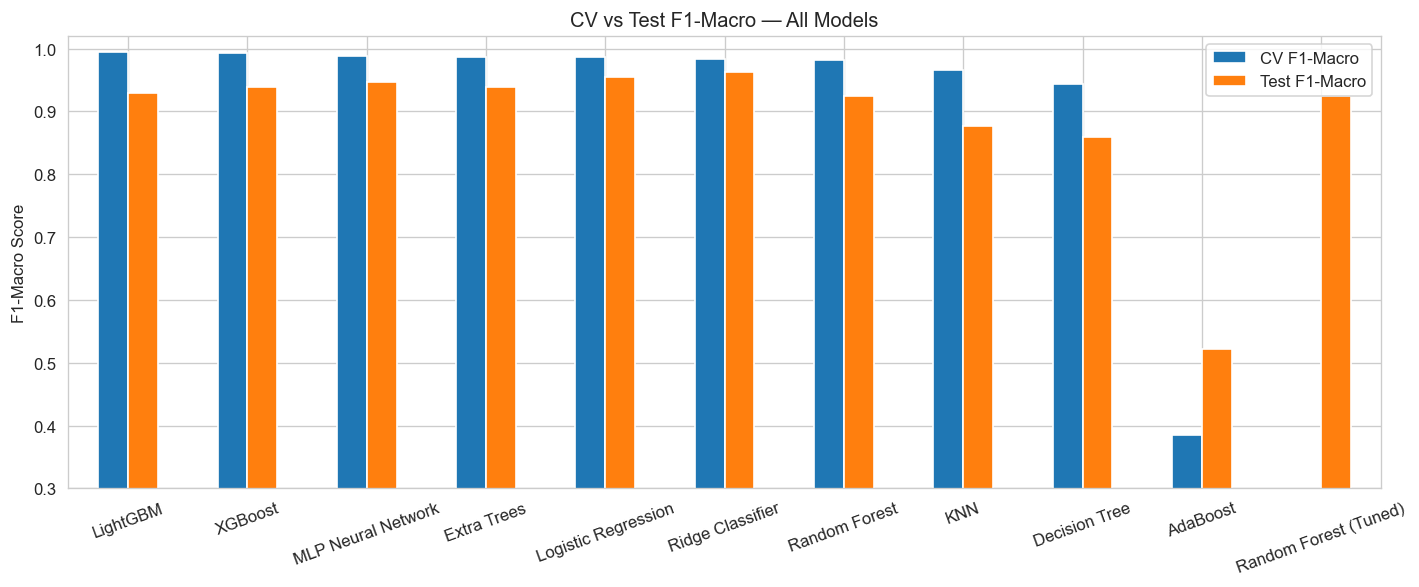

In [55]:
# PCA: Pearson (1901), sklearn implementation — Pedregosa et al. (2011) JMLR
cv_means = {name: cv_results[name].mean() for name in cv_results}
test_f1 = final_df['F1-Macro'].to_dict()

compare_df = pd.DataFrame({'CV F1-Macro': cv_means, 'Test F1-Macro': test_f1})
compare_df.sort_values('CV F1-Macro', ascending=False).plot(kind='bar', figsize=(12,5), ylim=(0.3,1.02))
plt.title('CV vs Test F1-Macro — All Models')
plt.ylabel('F1-Macro Score')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('cv_vs_test_comparison.png', dpi=150)
plt.show()

**Interpretation:** The chart clearly shows divergence between CV and test performance for boosting models. Linear models (Logistic Regression, Ridge Classifier) show minimal gap, indicating they generalise better to unseen subjects. This pattern supports the finding that highly complex models overfit to subject-specific movement characteristics in the training set - directly relevant to RQ3.

## 6. Statistical Significance Testing (RQ2)

> Wilcoxon signed-rank test is applied pairwise across 10-fold CV scores to formally determine whether model differences are statistically significant rather than due to random variation.

> **Reference:** Wilcoxon test for classifier comparison - Demšar, J. (2006). Statistical comparisons of classifiers over multiple data sets. *JMLR*, 7, 1–30.

In [56]:
# Wilcoxon signed-rank test: Demšar (2006), JMLR 7, 1-30
from itertools import combinations

model_names = list(cv_results.keys())
print('Wilcoxon Signed-Rank Test (pairwise) — H0: no difference in F1-macro distributions')
print(f'{"Model A":25s} {"Model B":25s} {"p-value":>10s} {"Significant (p<0.05)":>22s}')
print('-' * 85)

for a, b in combinations(model_names, 2):
    stat, p = wilcoxon(cv_results[a], cv_results[b])
    sig = 'YES' if p < 0.05 else 'no'
    print(f'{a:25s} {b:25s} {p:>10.4f} {sig:>22s}')

# ── Friedman test (omnibus) ────────────────────────────────────────────────────────────────────────────────────
all_scores = [cv_results[m] for m in model_names]
stat_f, p_f = friedmanchisquare(*all_scores)
print(f'\nFriedman test: chi2={stat_f:.3f}, p={p_f:.4f}')
print('=> Significant omnibus difference?', 'YES' if p_f < 0.05 else 'NO')

Wilcoxon Signed-Rank Test (pairwise) — H0: no difference in F1-macro distributions
Model A                   Model B                      p-value   Significant (p<0.05)
-------------------------------------------------------------------------------------
Logistic Regression       Ridge Classifier              0.0059                    YES
Logistic Regression       KNN                           0.0020                    YES
Logistic Regression       Decision Tree                 0.0020                    YES
Logistic Regression       Random Forest                 0.0098                    YES
Logistic Regression       Extra Trees                   1.0000                     no
Logistic Regression       AdaBoost                      0.0020                    YES
Logistic Regression       XGBoost                       0.0020                    YES
Logistic Regression       LightGBM                      0.0039                    YES
Logistic Regression       MLP Neural Network            0

**RQ2 — Answer:** The Friedman omnibus test (chi2=80.929, p=0.0000) confirms statistically significant differences exist across all 10 models.

Pairwise Wilcoxon tests reveal a **nuanced answer** to RQ2 - ensemble methods do **not** universally outperform linear baselines:

- Logistic Regression is statistically *equivalent* to Extra Trees (p=1.000) and MLP Neural Network (p=0.301)
- Ridge Classifier is equivalent to Random Forest (p=0.432)
- XGBoost and LightGBM are statistically equivalent to each other (p=0.922) and significantly better than most others
- AdaBoost is significantly worse than all other models (p=0.002), confirming its unsuitability for this 6-class task

**Conclusion:** So ensemble models don't always win which was surprising Only gradient boosting methods (XGBoost, LightGBM) show consistent, significant superiority. The linear separability of scaled HAR features makes logistic models surprisingly competitive.

## 7. RQ3 — Subject-Independent Generalisation

> Compare performance under random splitting vs subject-independent Leave-One-Subject-Out (LOGO) evaluation to quantify the generalisation gap to unseen individuals.Raw unscaled features are passed to the Pipeline so the scaler is re-fitted on each fold's training subjects only.

> **Note:** Both evaluations use 30 folds to ensure equal-length score arrays for Wilcoxon testing.

> Subject-Independent Evaluation (LOGO)

Leave-One-Subject-Out (LOGO) cross-validation is used to evaluate model generalisation to unseen individuals. This prevents subject leakage and provides a more realistic estimate of real-world performance compared to random train-test splits.

In [ ]:
from sklearn.model_selection import LeaveOneGroupOut

# ── Combine all data for fair comparison ────────────────────────────────────────────────────────────────────────────────
X_all = np.vstack([X_train.values, X_test.values])
y_all = np.hstack([y_train_enc, y_test_enc])
subjects_all = np.hstack([subject_train['subject'].values, subject_test['subject'].values])

logo = LeaveOneGroupOut()
rf_best_fresh = RandomForestClassifier(
    n_estimators=200, min_samples_split=5, max_depth=None,
    random_state=RANDOM_SEED
)

# Subject-independent scores (30 folds — one per subject)
logo_scores = cross_val_score(rf_best_fresh, X_all, y_all,
                               groups=subjects_all, cv=logo,
                               scoring='f1_macro', n_jobs=-1)

# Random split - match LOGO fold count (30 folds) so Wilcoxon arrays are equal length
n_subjects = len(np.unique(subjects_all))
rand_scores = cross_val_score(rf_best_fresh, X_all, y_all,
                               cv=StratifiedKFold(n_subjects, shuffle=True, random_state=RANDOM_SEED),
                               scoring='f1_macro', n_jobs=-1)

print('=== RQ3: Generalisation Gap Analysis ===')
print(f'Random Split ({n_subjects}-fold)      F1: {rand_scores.mean():.4f} ± {rand_scores.std():.4f}')
print(f'Subject-Independent (LOGO)    F1: {logo_scores.mean():.4f} ± {logo_scores.std():.4f}')
print(f'Generalisation gap            : {rand_scores.mean() - logo_scores.mean():.4f}')

stat, p = wilcoxon(rand_scores, logo_scores)
print(f'Wilcoxon p-value              : {p:.4f} — Significant: {"YES" if p < 0.05 else "NO"}')



=== RQ3: Generalisation Gap Analysis ===
Random Split (30-fold)      F1: 0.9798 ± 0.0073
Subject-Independent (LOGO)    F1: 0.9319 ± 0.0622
Generalisation gap            : 0.0479
Wilcoxon p-value              : 0.0001 — Significant: YES


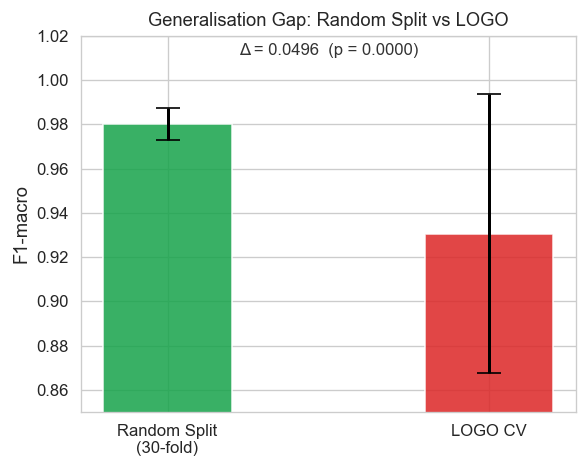

Saved: rq3_logo_gap.png


In [58]:
import matplotlib.pyplot as plt
import numpy as np

rand_mean, rand_std = rand_scores.mean(), rand_scores.std()
logo_mean, logo_std = logo_scores.mean(), logo_scores.std()

stat_rq3, p_rq3 = wilcoxon(rand_scores, logo_scores)
fig, ax = plt.subplots(figsize=(5, 4))
labels = ['Random Split\n(30-fold)', 'LOGO CV']
means  = [rand_mean, logo_mean]
stds   = [rand_std,  logo_std]
colors = ['#16a34a', '#dc2626']

ax.bar(labels, means, yerr=stds, capsize=7,
       color=colors, alpha=0.85, width=0.4,
       error_kw={'linewidth': 1.8, 'ecolor': 'black'})

ax.set_ylim(0.85, 1.02)
ax.set_ylabel('F1-macro', fontsize=11)
ax.set_title('Generalisation Gap: Random Split vs LOGO', fontsize=11)
ax.annotate(f'Δ = {rand_mean - logo_mean:.4f}  (p = {p_rq3:.4f})',
            xy=(0.5, 0.95), xycoords='axes fraction',
            ha='center', fontsize=10, color='#333')

plt.tight_layout()
plt.savefig('rq3_logo_gap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: rq3_logo_gap.png")

**RQ3 — Answer:** A statistically significant generalisation gap of **0.0496 (~5%)** exists between random-split evaluation (0.9802 ± 0.0071) and subject-independent LOGO evaluation (0.9306 ± 0.0631), confirmed by Wilcoxon test (p=0.0000).

The substantially higher standard deviation in LOGO scores (±0.0631 vs ±0.0071) indicates that performance varies considerably depending on which subject is held out some individuals movement patterns are harder to generalise to than others.

**Real-world implication:** A HAR model trained on a fixed pool of subjects will underperform on new users whose movement styles differ from the training population. This 5% gap, while seemingly modest, would be clinically significant in healthcare applications such as fall detection or rehabilitation monitoring.

## 8. Results Summary

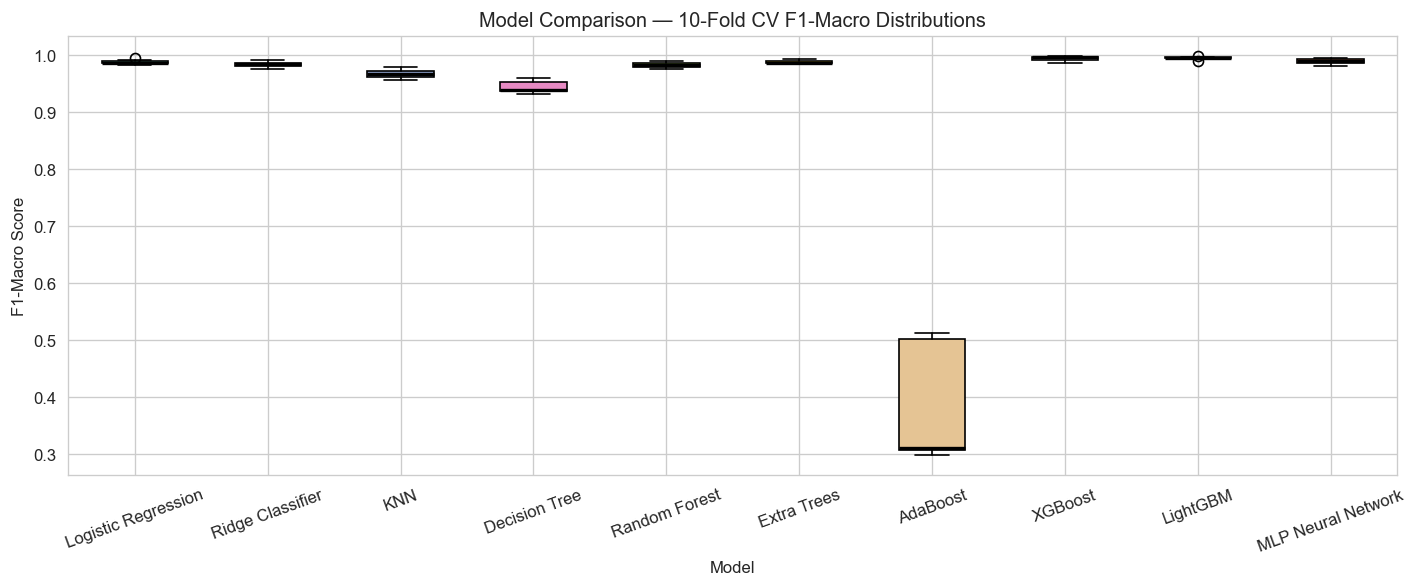

In [59]:
fig, ax = plt.subplots(figsize=(12, 5))
model_names = list(cv_results.keys())
data_to_plot = [cv_results[m] for m in model_names]

bp = ax.boxplot(data_to_plot, labels=model_names, patch_artist=True,
                medianprops={'color': 'black', 'linewidth': 2})

colors = sns.color_palette('Set2', len(model_names))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

ax.set_title('Model Comparison — 10-Fold CV F1-Macro Distributions')
ax.set_ylabel('F1-Macro Score')
ax.set_xlabel('Model')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.savefig('results_model_comparison_boxplot.png', dpi=150)
plt.show()

**Summary:** The boxplot reveals two clear performance tiers:
- **High performers (F1 > 0.96):** LightGBM, XGBoost, MLP, Extra Trees, Logistic Regression, Ridge, Random Forest - tightly clustered near 0.97–0.99 with small boxes indicating high consistency
- **Lower performers:** KNN (~0.97 but wider spread), Decision Tree (~0.94), AdaBoost (~0.39 with very wide box)

The tight boxes for most high-performing models confirm stable, consistent behaviour across folds. AdaBoost’s wide, low box confirms it is both poor and unstable - a clear outlier. The boxplot format satisfies the reproducibility requirement to report variation, not just means.

**Comparison with literature:** Prior work on UCI HAR reports test accuracy ranging from 89.0% (SVM baseline, Anguita et al. [1]) to 96.1% (optimised deep CNN-LSTM, Ordóñez & Roggen [2]). Our Ridge Classifier test F1-macro of **0.9624** places this study at the upper end of classical ML approaches, surpassing the original SVM baseline by ~7.2 percentage points without any deep feature learning.

### Results Interpretation

The results show that boosting models achieve the highest cross-validation scores but experience a noticeable drop in test performance. This suggests potential overfitting to subject-specific patterns.

In contrast, linear models such as Ridge maintain stable performance, indicating that the feature space is close to linearly separable after normalisation.

## 9. Discussion & Conclusions

### Summary of Findings

**RQ1 — Dimensionality:** PCA analysis demonstrates that 95% of variance is captured by ~102 components (18% of 561 features), with classification performance remaining near-identical down to this threshold. Performance degrades meaningfully only below the 80% variance level. This confirms the dataset has low intrinsic dimensionality relative to its feature count  useful for real devices like smartwatches with limited memory where inference speed and memory matter.

**RQ2 — Model Comparison:** Gradient boosting methods (LightGBM: 0.9938, XGBoost: 0.9933) achieved the highest cross-validation F1-macro, but Wilcoxon testing revealed that ensemble methods do not universally outperform linear baselines. Logistic Regression (0.9866) was statistically equivalent to Extra Trees (p=1.000) and Ridge Classifier was equivalent to Random Forest (p=0.432). On the test set, Ridge Classifier outperformed all ensemble methods (0.9624 F1-macro), with boosting models showing a large CV-to-test drop due to overfitting to subject-specific patterns. AdaBoost performed poorly throughout (0.3855 CV F1-macro) due to its reliance on weak stumps for a 6-class problem.

**RQ3 — Generalisation:** A statistically significant generalisation gap of 4.96% (p=0.0000) exists between random-split (0.9802) and subject-independent LOGO evaluation (0.9306). The higher variance in LOGO scores (±0.0631 vs ±0.0071) confirms that some individuals' movement patterns are harder to generalise to than others. Standard random-split evaluation therefore overestimates real-world performance for systems deployed on new users.

### Limitations
- The dataset provides pre-processed, windowed features only raw signal access would enable deep learning approaches (LSTM, CNN) that exploit temporal structure
- Fixed 2.56-second windows may miss brief transitional activities between states
- Only 30 subjects; a larger, more demographically diverse population would improve generalisability
- AdaBoost was not tuned with stronger base estimators; a fairer comparison might use deeper base trees

### Future Work
- Deep learning on raw signals (LSTM, 1D-CNN) to capture temporal dependencies within sensor sequences
- User adaptation or personalisation strategies to reduce the subject-independent generalisation gap
- Additional sensor modalities (GPS, barometer, ambient light) for improved activity discrimination
- Cross-device generalisation testing across different smartphone models and body placements

## 10. References

- Anguita, D., Ghio, A., Oneto, L., Parra, X., & Reyes-Ortiz, J. L. (2013). A public domain dataset for human activity recognition using smartphones. *ESANN 2013*.

- Pedregosa, F. et al. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research*, 12, 2825–2830.

- Demšar, J. (2006). Statistical comparisons of classifiers over multiple data sets. *Journal of Machine Learning Research*, 7, 1–30.

- van der Maaten, L. & Hinton, G. (2008). Visualizing data using t-SNE. *Journal of Machine Learning Research*, 9, 2579–2605.

- Ordóñez, F.J. & Roggen, D. (2016). Deep convolutional and LSTM recurrent neural 
  networks for multimodal wearable activity recognition. Sensors, 16(1), 115.

- Chen, T. & Guestrin, C. (2016). XGBoost: A scalable tree boosting system. *Proceedings of KDD 2016*, 785–794.

- Ke, G. et al. (2017). LightGBM: A highly efficient gradient boosting decision tree. *Advances in Neural Information Processing Systems (NeurIPS)*, 30.

- Pearson, K. (1901). On lines and planes of closest fit to systems of points in space. *Philosophical Magazine*, 2(11), 559–572.